# Chapter 2 — Discrete Random Variables and Their Distributions (R notebook)

> Companion to [`notes.md`](../notes.md), [`worked-examples.md`](../worked-examples.md), and [`exercises.md`](../exercises.md).

This notebook has seven sections, each tied to a specific section of `notes.md`:

1. **Anchor problem (§2.0, §2.12):** the bank call-center Poisson spike — analytic + Monte Carlo + visualization.
2. **Bernoulli and Binomial (§2.3–§2.4):** indicators, the Binomial shape, simulation.
3. **Geometric and Negative Binomial (§2.6):** waiting-time distributions.
4. **Hypergeometric (§2.7):** sampling without replacement; quality-control worked example.
5. **Poisson as a Binomial limit (§2.9):** the convergence visualization.
6. **Functions of RVs (§2.10):** pushforward for `Y = |X - 2|`.
7. **Short R exercises with solutions.**

## Setup

This notebook uses the **R kernel** (IRkernel). If you see a Python kernel in the top right, pick *Kernel → Change Kernel… → R*. Install IRkernel once from an R console with:

```R
install.packages(c("IRkernel", "tidyverse", "ggplot2", "gridExtra"))
IRkernel::installspec()
```

In [1]:
suppressPackageStartupMessages({
  library(tidyverse)
  library(ggplot2)
  library(gridExtra)
})

theme_set(theme_minimal(base_size = 12))
set.seed(42)

## 1. Anchor: the bank call-center spike (§2.0, §2.12)

A busy commercial bank's call center averages 5 customer calls per minute. At 9:03 AM, the floor supervisor watches the dashboard tick up to 12 calls in a single minute and escalates — is this evidence that something is broken, or is 12 calls/minute a perfectly ordinary Poisson fluctuation?

We model `X` = calls in a given minute as `X ~ Poisson(λ = 5)` and compute `P(X ≥ 12)`, then simulate to verify.

In [2]:
# Analytic answer — one line of R
p_spike_analytic <- 1 - ppois(11, lambda = 5)
cat(sprintf("P(X >= 12 | Poisson(5)) = %.6f\n", p_spike_analytic))
cat(sprintf("One spike every  %.1f  minutes on average\n", 1 / p_spike_analytic))
cat(sprintf("Expected spikes per 9-hour shift: %.2f (out of 540 minutes)\n",
            540 * p_spike_analytic))

P(X >= 12 | Poisson(5)) = 0.005453


One spike every  183.4  minutes on average


Expected spikes per 9-hour shift: 2.94 (out of 540 minutes)


In [3]:
# Monte Carlo: simulate 100,000 one-minute windows, count how many hit >= 12.
n_sim <- 1e5
sim_minutes <- rpois(n_sim, lambda = 5)
p_spike_mc <- mean(sim_minutes >= 12)
cat(sprintf("Analytic P(X >= 12): %.6f\n", p_spike_analytic))
cat(sprintf("Simulated P(X >= 12): %.6f (n = %d)\n", p_spike_mc, n_sim))
cat(sprintf("Absolute error: %.6f\n", abs(p_spike_mc - p_spike_analytic)))

Analytic P(X >= 12): 0.005453


Simulated P(X >= 12): 0.005720 (n = 100000)


Absolute error: 0.000267


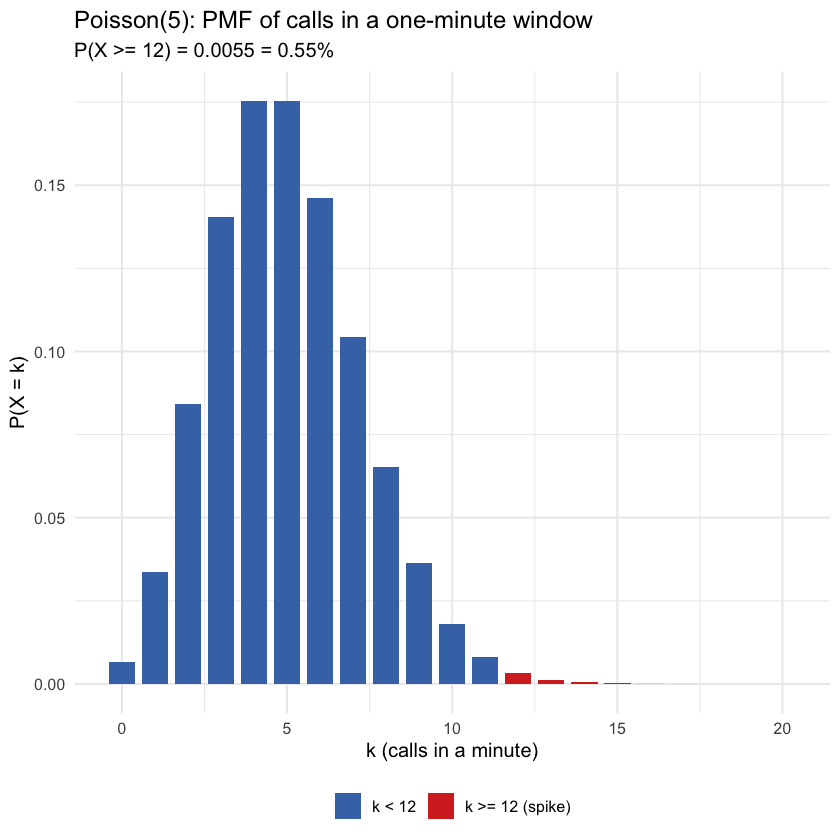

In [4]:
# Visualize the Poisson(5) PMF with the tail k >= 12 shaded red.
ks <- 0:20
pmf_df <- tibble(
  k = ks,
  p = dpois(ks, lambda = 5),
  tail = k >= 12
)

ggplot(pmf_df, aes(x = k, y = p, fill = tail)) +
  geom_col(width = 0.8) +
  scale_fill_manual(values = c("FALSE" = "#4575b4", "TRUE" = "#d73027"),
                    labels = c("FALSE" = "k < 12", "TRUE" = "k >= 12 (spike)"),
                    name = NULL) +
  labs(
    title = "Poisson(5): PMF of calls in a one-minute window",
    subtitle = sprintf("P(X >= 12) = %.4f = %.2f%%", p_spike_analytic, p_spike_analytic * 100),
    x = "k (calls in a minute)",
    y = "P(X = k)"
  ) +
  theme(legend.position = "bottom")

## 2. Bernoulli and Binomial (§2.3–§2.4)

Every event in Ch 1 gives rise to a **Bernoulli RV** via its indicator. The Binomial is a sum of `n` independent Bernoullis — the PMF `C(n, k) · p^k · (1-p)^(n-k)` derives directly from Ch 1's counting (§1.5) and independence (§1.13).

In [5]:
# Bernoulli indicator: roll a fair die, X = 1 if roll is 6, else 0.
# Simulate 10,000 rolls and check the empirical mean converges to 1/6.
n_rolls <- 1e4
rolls <- sample(1:6, n_rolls, replace = TRUE)
X <- as.integer(rolls == 6)
cat(sprintf("Empirical mean of X over %d rolls: %.4f\n", n_rolls, mean(X)))
cat(sprintf("Theoretical mean (= P(X = 1) = P(roll = 6)): %.4f\n", 1/6))

Empirical mean of X over 10000 rolls: 0.1670


Theoretical mean (= P(X = 1) = P(roll = 6)): 0.1667


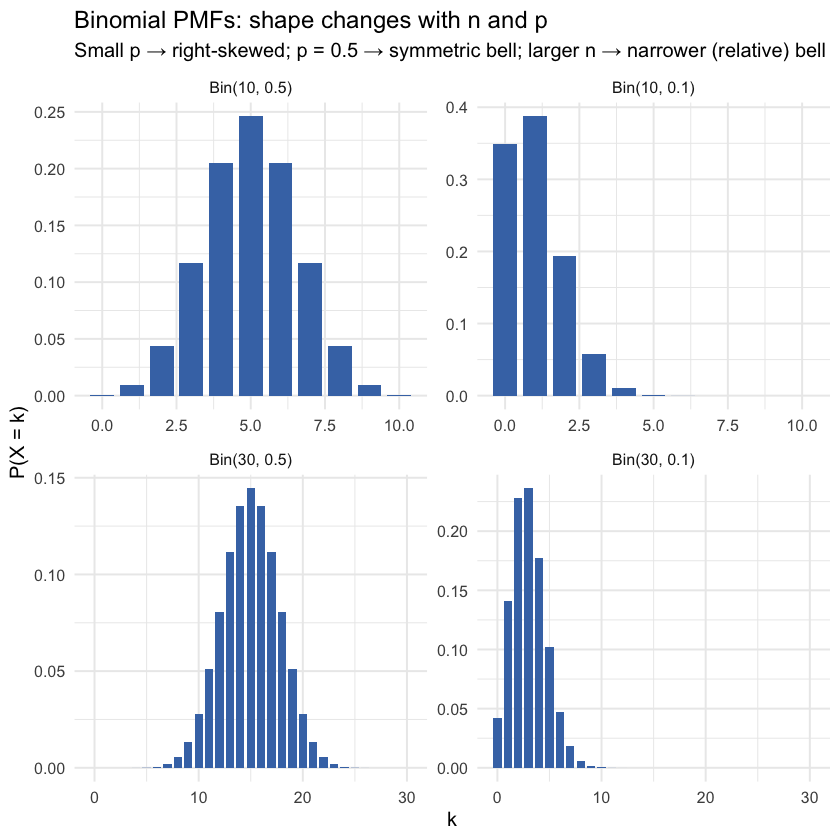

In [6]:
# Binomial(n, p) PMF shapes side by side.
binom_df <- bind_rows(
  tibble(n = 10, p = 0.5,  label = "Bin(10, 0.5)"),
  tibble(n = 10, p = 0.1,  label = "Bin(10, 0.1)"),
  tibble(n = 30, p = 0.5,  label = "Bin(30, 0.5)"),
  tibble(n = 30, p = 0.1,  label = "Bin(30, 0.1)")
) %>%
  rowwise() %>%
  mutate(k = list(0:n), p_k = list(dbinom(0:n, n, p))) %>%
  unnest(c(k, p_k)) %>%
  mutate(label = factor(label, levels = c("Bin(10, 0.5)", "Bin(10, 0.1)",
                                          "Bin(30, 0.5)", "Bin(30, 0.1)")))

ggplot(binom_df, aes(x = k, y = p_k)) +
  geom_col(fill = "#4575b4", width = 0.8) +
  facet_wrap(~ label, scales = "free", ncol = 2) +
  labs(title = "Binomial PMFs: shape changes with n and p",
       subtitle = "Small p → right-skewed; p = 0.5 → symmetric bell; larger n → narrower (relative) bell",
       x = "k", y = "P(X = k)")

In [7]:
# Verify Worked Example 2: Bin(5, 0.5), P(X = 3).
# Analytic: C(5,3) * 0.5^5 = 10/32 = 0.3125
cat(sprintf("Analytic dbinom(3, 5, 0.5): %.6f\n", dbinom(3, 5, 0.5)))

# Simulate
n_sim <- 1e5
sim <- rbinom(n_sim, size = 5, prob = 0.5)
cat(sprintf("Simulated P(X = 3) (n = %d): %.6f\n", n_sim, mean(sim == 3)))

Analytic dbinom(3, 5, 0.5): 0.312500


Simulated P(X = 3) (n = 100000): 0.308500


## 3. Geometric and Negative Binomial (§2.6)

`Geometric(p)` = trial of first success. `NegBinomial(r, p)` = trial of r-th success. Both derive from independent Bernoulli trials — Ch 1 §1.13 in new clothes.

**Convention caveat.** R's `dgeom` uses "failures before first success" (support 0, 1, 2, …). Our curriculum uses "trial of first success" (support 1, 2, 3, …). Translation: our `P(X = k) = dgeom(k - 1, p)`.

In [8]:
# Worked Example 3: roll a die until a 6; P(first 6 on roll 3).
p_e3_analytic <- (5/6)^2 * (1/6)
cat(sprintf("Analytic P(first 6 on roll 3) = 25/216 = %.6f\n", p_e3_analytic))
cat(sprintf("R's dgeom(2, 1/6) (their convention): %.6f\n", dgeom(2, 1/6)))

# Simulate: roll until 6, record which roll # got the 6.
n_sim <- 1e5
first_six <- integer(n_sim)
for (i in seq_len(n_sim)) {
  # Geometric(1/6) via rgeom + 1 (add 1 to convert to our convention)
  first_six[i] <- rgeom(1, 1/6) + 1
}
cat(sprintf("Simulated P(first 6 on roll 3) (n = %d): %.6f\n",
            n_sim, mean(first_six == 3)))

Analytic P(first 6 on roll 3) = 25/216 = 0.115741


R's dgeom(2, 1/6) (their convention): 0.115741


Simulated P(first 6 on roll 3) (n = 100000): 0.116520


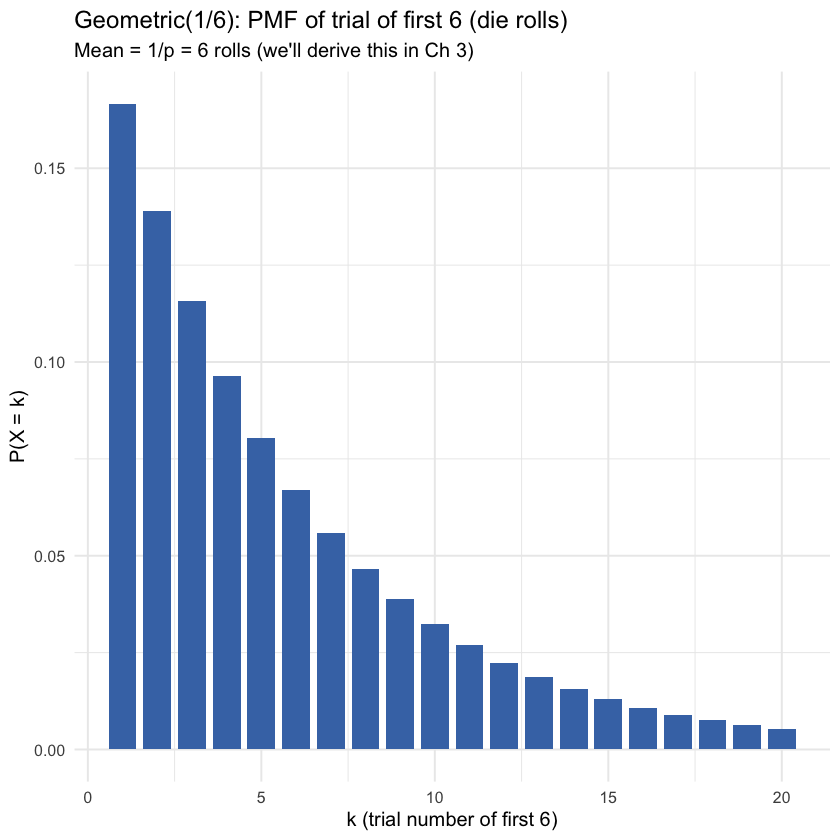

In [9]:
# Geometric PMF plot (our convention): P(X = k) for k = 1..20, p = 1/6
ks <- 1:20
geom_df <- tibble(
  k = ks,
  p = (5/6)^(ks - 1) * (1/6)
)

ggplot(geom_df, aes(x = k, y = p)) +
  geom_col(fill = "#4575b4", width = 0.8) +
  labs(title = "Geometric(1/6): PMF of trial of first 6 (die rolls)",
       subtitle = sprintf("Mean = 1/p = 6 rolls (we'll derive this in Ch 3)"),
       x = "k (trial number of first 6)", y = "P(X = k)")

## 4. Hypergeometric (§2.7)

Sampling without replacement. Worked Example 5: 100-item shipment with 8 defective, inspect 10, compute `P(X ≥ 2)` exactly with `dhyper`, then verify by simulation.

In [10]:
# Analytic: P(X >= 2) with m = 8 defectives, n = 92 good, k = 10 drawn
p_e5_analytic <- 1 - dhyper(0, m = 8, n = 92, k = 10) -
                     dhyper(1, m = 8, n = 92, k = 10)
cat(sprintf("Analytic P(X >= 2) Hypergeometric: %.6f\n", p_e5_analytic))

# Binomial approximation (wrong-but-close because n/N = 10%)
p_e5_binom <- 1 - pbinom(1, size = 10, prob = 0.08)
cat(sprintf("Binomial approximation (wrong-but-close): %.6f\n", p_e5_binom))

# Simulate: draw 10 from a 100-item urn (8 defective), count defectives.
n_sim <- 1e5
urn <- c(rep(1, 8), rep(0, 92))  # 1 = defective
sim <- replicate(n_sim, sum(sample(urn, 10, replace = FALSE)))
cat(sprintf("Simulated P(X >= 2) (n = %d): %.6f\n",
            n_sim, mean(sim >= 2)))

Analytic P(X >= 2) Hypergeometric: 0.181950


Binomial approximation (wrong-but-close): 0.187882


Simulated P(X >= 2) (n = 100000): 0.181200


## 5. Poisson as a Binomial limit (§2.9)

The Poisson's PMF `λ^k · e^(-λ) / k!` is the `n → ∞` limit of `Binomial(n, λ/n)` PMFs. Visually: as `n` grows, the Binomial(n, λ/n) PMF converges to Poisson(λ).

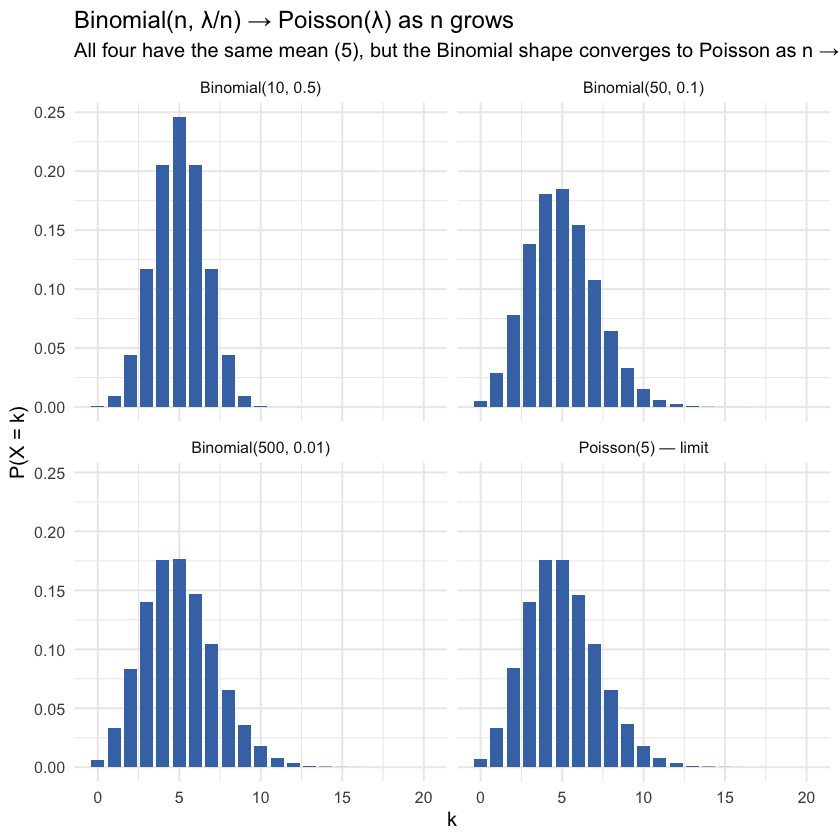

In [11]:
# Convergence plot: Binomial(n, 5/n) for n = 10, 50, 500 vs. Poisson(5)
lambda <- 5
ks <- 0:20

convergence_df <- bind_rows(
  tibble(dist = "Binomial(10, 0.5)",     k = ks, p = dbinom(ks, 10, lambda/10)),
  tibble(dist = "Binomial(50, 0.1)",     k = ks, p = dbinom(ks, 50, lambda/50)),
  tibble(dist = "Binomial(500, 0.01)",   k = ks, p = dbinom(ks, 500, lambda/500)),
  tibble(dist = "Poisson(5) — limit",    k = ks, p = dpois(ks, lambda))
) %>% mutate(dist = factor(dist, levels = c(
  "Binomial(10, 0.5)", "Binomial(50, 0.1)", "Binomial(500, 0.01)", "Poisson(5) — limit"
)))

ggplot(convergence_df, aes(x = k, y = p)) +
  geom_col(fill = "#4575b4", width = 0.8) +
  facet_wrap(~ dist, ncol = 2) +
  labs(title = "Binomial(n, λ/n) → Poisson(λ) as n grows",
       subtitle = "All four have the same mean (5), but the Binomial shape converges to Poisson as n → ∞",
       x = "k", y = "P(X = k)")

In [12]:
# Numerical convergence check — compare P(X = 3) for each distribution.
cat("P(X = 3) across the convergence sequence:\n")
for (n in c(10, 50, 500, 5000)) {
  p_bin <- dbinom(3, n, lambda/n)
  cat(sprintf("  Binomial(%4d, %.4f):  %.6f\n", n, lambda/n, p_bin))
}
cat(sprintf("  Poisson(5) (limit):    %.6f\n", dpois(3, lambda)))

P(X = 3) across the convergence sequence:


  Binomial(  10, 0.5000):  0.117188
  Binomial(  50, 0.1000):  0.138565
  Binomial( 500, 0.0100):  0.140230
  Binomial(5000, 0.0010):  0.140360


  Poisson(5) (limit):    0.140374


## 6. Resolving the anchor — how many spikes per shift?

Worked Example 10: under the null `X_t ~ Poisson(5)` across 540 minutes per shift, how often do we see **3 or more** spike minutes (≥ 12 calls)?

In [13]:
p_spike <- 1 - ppois(11, lambda = 5)
exp_spikes <- 540 * p_spike

# Y = number of spike minutes per shift ~ Binomial(540, p_spike) ≈ Poisson(exp_spikes)
p_3 <- 1 - ppois(2, lambda = exp_spikes)
p_6 <- 1 - ppois(5, lambda = exp_spikes)
p_7 <- 1 - ppois(6, lambda = exp_spikes)

cat(sprintf("P(single minute is a spike): %.6f\n", p_spike))
cat(sprintf("Expected spikes per shift:   %.3f\n", exp_spikes))
cat(sprintf("P(Y >= 3): %.4f    <- supervisor saw 3\n", p_3))
cat(sprintf("P(Y >= 6): %.4f\n", p_6))
cat(sprintf("P(Y >= 7): %.4f    <- plausibly 'unusual' threshold\n", p_7))

cat(sprintf("\nConclusion: 3 spikes in a shift has %.0f%% chance under the null.\n",
            p_3 * 100))
cat("The supervisor's observation is NOT evidence of anomaly.\n")

P(single minute is a spike): 0.005453


Expected spikes per shift:   2.945


P(Y >= 3): 0.5643    <- supervisor saw 3


P(Y >= 6): 0.0784


P(Y >= 7): 0.0308    <- plausibly 'unusual' threshold



Conclusion: 3 spikes in a shift has 56% chance under the null.


The supervisor's observation is NOT evidence of anomaly.


Simulated mean spikes/shift: 2.961 (theory: 2.945)


Simulated P(Y >= 3): 0.5622 (theory: 0.5643)


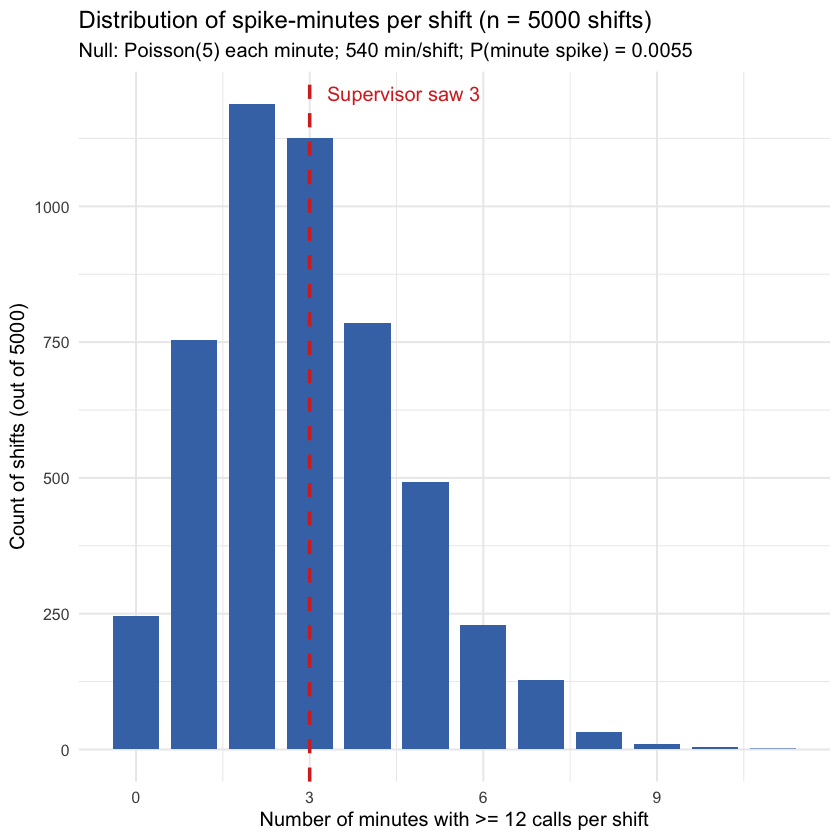

In [14]:
# Simulate whole shifts. For each shift, draw 540 Poisson(5) minute counts,
# count spikes. Histogram the distribution of spikes-per-shift.
n_shifts <- 5000
spikes_per_shift <- integer(n_shifts)
for (i in seq_len(n_shifts)) {
  minute_counts <- rpois(540, lambda = 5)
  spikes_per_shift[i] <- sum(minute_counts >= 12)
}

# Quick tail probabilities
cat(sprintf("Simulated mean spikes/shift: %.3f (theory: %.3f)\n",
            mean(spikes_per_shift), exp_spikes))
cat(sprintf("Simulated P(Y >= 3): %.4f (theory: %.4f)\n",
            mean(spikes_per_shift >= 3), p_3))

ggplot(tibble(spikes = spikes_per_shift), aes(x = spikes)) +
  geom_bar(fill = "#4575b4", width = 0.8) +
  geom_vline(xintercept = 3, color = "#d73027", linetype = "dashed", linewidth = 1) +
  annotate("text", x = 3.3, y = Inf, vjust = 2, label = "Supervisor saw 3",
           color = "#d73027", hjust = 0) +
  labs(title = sprintf("Distribution of spike-minutes per shift (n = %d shifts)", n_shifts),
       subtitle = sprintf("Null: Poisson(5) each minute; 540 min/shift; P(minute spike) = %.4f",
                          p_spike),
       x = "Number of minutes with >= 12 calls per shift",
       y = "Count of shifts (out of 5000)")

## 7. Functions of RVs — pushforward (§2.10)

Exercise 9: let `X ~ Binomial(4, 0.5)` and `Y = |X - 2|`. The pushforward PMF collects preimages and sums their probabilities.

In [15]:
# Analytic: PMF of X, then push forward to Y = |X - 2|.
pmf_X <- dbinom(0:4, size = 4, prob = 0.5)
names(pmf_X) <- as.character(0:4)
print(pmf_X)

y_values <- abs((0:4) - 2)
pmf_Y <- tapply(pmf_X, y_values, sum)
cat("\nPMF of Y = |X - 2|:\n")
print(pmf_Y)
cat(sprintf("Sums to %.6f\n", sum(pmf_Y)))

# Cross-check with simulation
n_sim <- 1e5
X_sim <- rbinom(n_sim, 4, 0.5)
Y_sim <- abs(X_sim - 2)
cat("\nSimulated PMF of Y:\n")
print(table(Y_sim) / n_sim)

     0      1      2      3      4 
0.0625 0.2500 0.3750 0.2500 0.0625 



PMF of Y = |X - 2|:


    0     1     2 
0.375 0.500 0.125 


Sums to 1.000000



Simulated PMF of Y:


Y_sim
      0       1       2 
0.37277 0.50193 0.12530 


## 8. R exercises (solutions included)

Three short R-first problems that build on the chapter's simulations.

**R1.** A factory's defect rate is 2%. In a batch of 50 items, (a) compute `P(exactly 2 defects)` analytically, and (b) verify by simulating 10,000 batches.

**R2.** A radioactive source emits particles at rate λ = 3 per second. Across 60 seconds, simulate the total emission and compare the histogram to a Poisson(180) shape.

**R3.** Extend the bank example: if the true rate is actually `λ = 7` (not 5), what's the probability of seeing a `≥ 12`-call minute? Compute analytically and verify by simulating 100,000 minutes at each rate.

In [16]:
# R1 — Binomial(50, 0.02)
p_r1_analytic <- dbinom(2, size = 50, prob = 0.02)
cat(sprintf("R1 analytic P(X = 2) = %.6f\n", p_r1_analytic))

sim <- rbinom(1e4, size = 50, prob = 0.02)
cat(sprintf("R1 simulated P(X = 2) = %.6f\n", mean(sim == 2)))

R1 analytic P(X = 2) = 0.185801


R1 simulated P(X = 2) = 0.190000


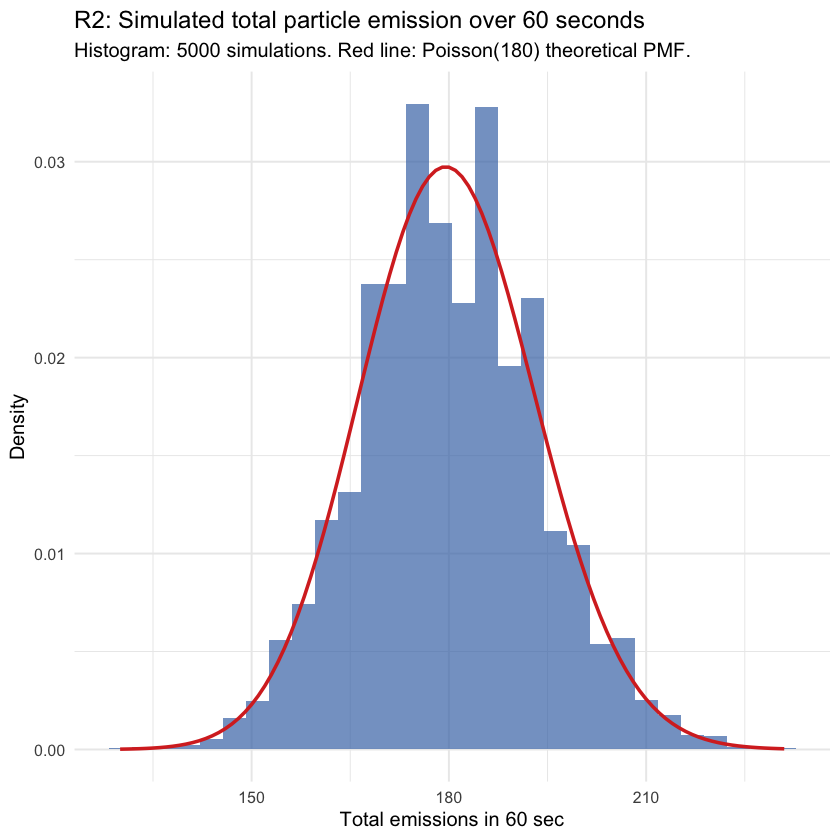

In [17]:
# R2 — radioactive decay, 60 seconds at rate 3/sec.
# Total particles across 60 seconds = sum of 60 independent Poisson(3) = Poisson(180).
n_sim <- 5000
totals <- rpois(n_sim, lambda = 180)

# Theoretical PMF over the observed range
k_range <- floor(min(totals)):ceiling(max(totals))
theory_df <- tibble(k = k_range, p = dpois(k_range, 180))

ggplot(tibble(totals = totals), aes(x = totals)) +
  geom_histogram(aes(y = after_stat(density)), bins = 30,
                 fill = "#4575b4", alpha = 0.7) +
  geom_line(data = theory_df, aes(x = k, y = p), color = "#d73027", linewidth = 1) +
  labs(title = "R2: Simulated total particle emission over 60 seconds",
       subtitle = "Histogram: 5000 simulations. Red line: Poisson(180) theoretical PMF.",
       x = "Total emissions in 60 sec", y = "Density")

In [18]:
# R3 — compare spike rate at λ = 5 vs λ = 7.
p_spike_5 <- 1 - ppois(11, lambda = 5)
p_spike_7 <- 1 - ppois(11, lambda = 7)
cat(sprintf("Analytic P(X >= 12 | Pois(5)) = %.6f\n", p_spike_5))
cat(sprintf("Analytic P(X >= 12 | Pois(7)) = %.6f\n", p_spike_7))
cat(sprintf("Ratio (7 / 5): %.1fx — a 40%% rate increase doubles-and-more the spike risk\n",
            p_spike_7 / p_spike_5))

# Simulate
n_sim <- 1e5
cat(sprintf("\nSimulated P(spike | lambda = 5): %.6f\n",
            mean(rpois(n_sim, 5) >= 12)))
cat(sprintf("Simulated P(spike | lambda = 7): %.6f\n",
            mean(rpois(n_sim, 7) >= 12)))

Analytic P(X >= 12 | Pois(5)) = 0.005453


Analytic P(X >= 12 | Pois(7)) = 0.053350


Ratio (7 / 5): 9.8x — a 40% rate increase doubles-and-more the spike risk



Simulated P(spike | lambda = 5): 0.005130


Simulated P(spike | lambda = 7): 0.052970


## What's next

Chapter 3 compresses each distribution to a few summary numbers — the **expectation** `E[X]`, **variance** `Var(X)`, and **covariance** `Cov(X, Y)`. We'll derive every `Mean` and `Variance` entry from Ch 2's summary table (§2.14), starting from the definition `E[X] = ∑_x x · P(X = x)` and building up **linearity of expectation** — arguably the single most useful identity in probability.

The summation-based derivations of the Binomial, Geometric, NegBin, and Poisson means all collapse to one-liners using indicator-RV sums + linearity. Once you have that technique, you can compute means of combinatorially wild distributions (like the expected number of fixed points in a random permutation) in a single sentence.